In [ ]:
from pathlib import Path
import xarray as xr
import xwrf
import salem

In [ ]:
res = 12     # 4km or 12 km resolution

fpattribs = {
    12: {
        'domain': 'd01'
    },
    4: {
        'domain': 'd02'
    }
}

wrfdir =  Path("/import/beegfs/CMIP6/wrf_era5/") 
invardir = wrfdir / f"{str(res).zfill(2)}km/invar/"
invarpath = invardir / f"geo_em.{fpattribs[res]['domain']}.nc"

In [ ]:
invarpath.exists()

True

In [ ]:
invar =  xr.open_dataset(invarpath, engine="netcdf4", decode_times=False, decode_coords='all')
invar = invar.rename({
    'XLAT_M': 'XLAT',
    'XLONG_M': 'XLONG',
    'HGT_M': 'elevation'
})
invar = invar.set_coords(['XLAT', 'XLONG'])
invar = invar.squeeze('Time', drop=True)

invar.attrs['Conventions'] = 'CF-1.7'
invar['XLAT'].attrs['units'] = 'degrees_north'
invar['XLONG'].attrs['units'] = 'degrees_east'
invar['XLONG'].attrs['standard_name'] = 'longitude'
invar['XLONG'].attrs['long_name'] = 'longitude'
invar['XLAT'].attrs['standard_name'] = 'latitude'
invar['XLAT'].attrs['long_name'] = 'latitude' 

In [ ]:
invar

<xarray.Dataset> Size: 29MB
Dimensions:     (south_north: 204, west_east: 264, south_north_stag: 205,
                 west_east_stag: 265, land_cat: 21, soil_cat: 16, month: 12)
Coordinates:
    XLAT        (south_north, west_east) float32 215kB ...
    XLONG       (south_north, west_east) float32 215kB ...
Dimensions without coordinates: south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month
Data variables: (12/51)
    Times       |S19 19B ...
    XLAT_V      (south_north_stag, west_east) float32 216kB ...
    XLONG_V     (south_north_stag, west_east) float32 216kB ...
    XLAT_U      (south_north, west_east_stag) float32 216kB ...
    XLONG_U     (south_north, west_east_stag) float32 216kB ...
    CLAT        (south_north, west_east) float32 215kB ...
    ...          ...
    OL1         (south_north, west_east) float32 215kB ...
    OL2         (south_north, west_east) float32 215kB ...
    OL3         (south_north, west_east) float32 215kB ...
    OL4         (south_north, west_east) float32 215kB ...
    VAR_SSO     (south_north, west_east) float32 215kB ...
    LAKE_DEPTH  (south_north, west_east) float32 215kB ...
Attributes: (12/49)
    TITLE:                           OUTPUT FROM GEOGRID V4.5
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        265
    SOUTH-NORTH_GRID_DIMENSION:      205
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    sr_y:                            1
    FLAG_MF_XY:                      1
    FLAG_LAI12M:                     1
    FLAG_VAR_SSO:                    1
    FLAG_LAKE_DEPTH:                 1
    Conventions:                     CF-1.7

#### Saving

In [ ]:
outfp = invardir/ f"elevation_{res}km.nc"
invar.elevation.to_netcdf(outfp, encoding={'elevation': {"zlib": True, "complevel": 5}})

In [ ]:
outfp = invardir/ f"landmask_{res}km.nc"
invar.LANDMASK.to_netcdf(outfp, encoding={'LANDMASK': {"zlib": True, "complevel": 5}})
outfp = invardir/ f"landuseindex_{res}km.nc"
invar.LU_INDEX.to_netcdf(outfp, encoding={'LU_INDEX': {"zlib": True, "complevel": 5}})

#### Plotting

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.cm import get_cmap
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

In [ ]:
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)

/tmp/ipykernel_1285769/3081670720.py:1: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(


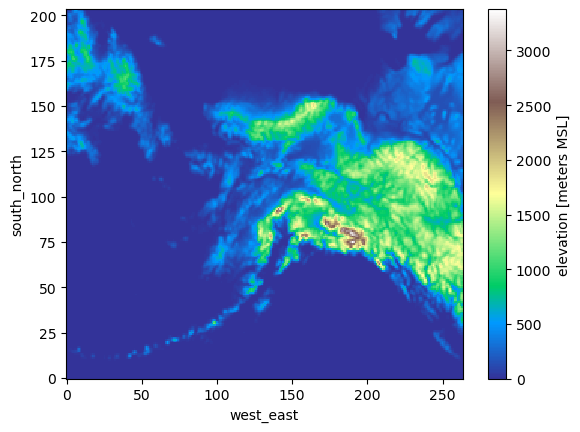

In [ ]:
invar.elevation.plot(cmap='terrain')

In [ ]:
levels = list(range(1, 23))

tab20_colors = list(plt.colormaps['tab20'].colors)
extra_color = ["#000000"]
new_cmap = mcolors.ListedColormap(tab20_colors + extra_color)
discrete_cmap = plt.colormaps['gist_ncar'].resampled(25)

In [ ]:
levels

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

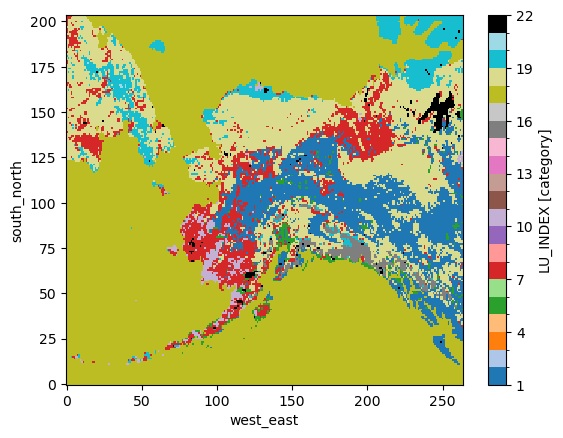

In [ ]:
invar.LU_INDEX.plot(levels=levels, cmap=new_cmap)

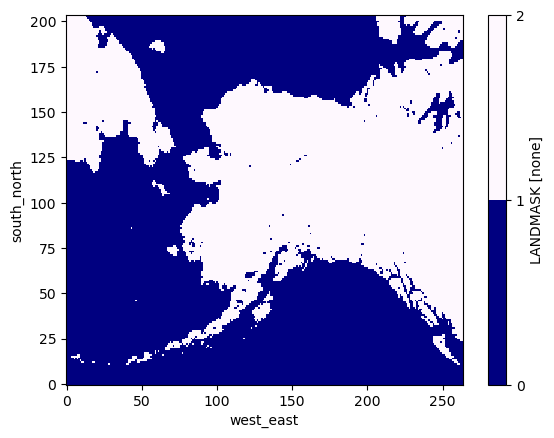

In [ ]:
invar.LANDMASK.plot(cmap='gist_ncar', levels=[0, 1, 2])